<a href="https://colab.research.google.com/github/limkc0116/FYP/blob/main/LIM_KANG_CHUN_yolov11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="vjuNLaTJfHC9loP7x85R")
project = rf.workspace("kangs-workspace-sc5tk").project("fyp-2-bglcr")
version = project.version(74)
dataset = version.download("yolov11")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 137.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to FYP-2-74 in yolov11:: 100%|██████████| 9361/9361 [00:01<00:00, 5107.47it/s]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!nvidia-smi

Sun Jun  7 10:08:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.5 MB/s eta 0:00:00


In [ ]:
!yolo detect train data=/content/FYP-2-74/data.yaml model=yolo11n.pt epochs=100 batch=8 lr0=0.01

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FYP-2-74/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, img

In [ ]:
from google.colab import drive
import shutil
import os

# 1. Mount Google Drive (if not already mounted)
drive.mount('/content/drive')

# 2. Define the paths
# Note: Double-check if your folder is 'train', 'train2', etc.
source_csv = '/content/runs/detect/train/results.csv'
destination_csv = '/content/drive/MyDrive/fyp1/finalyolov11_results.csv'

# 3. Copy the file
if os.path.exists(source_csv):
    shutil.copy(source_csv, destination_csv)
    print(f"Success! CSV saved to Drive as: {destination_csv}")
else:
    print(f"Error: Could not find the file at {source_csv}. Please check the folder path!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Success! CSV saved to Drive as: /content/drive/MyDrive/fyp1/finalyolov11_results.csv


In [ ]:
destination_csv = '/content/drive/MyDrive/fyp1/finalyolov11_results.csv'

In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

# Save weights
if os.path.exists('/content/runs/detect/train/weights/best.pt'):
    shutil.copy('/content/runs/detect/train/weights/best.pt', '/content/drive/MyDrive/fyp1/finalyolov11.pt')
    print("Weights saved!")

# Save CSV history
if os.path.exists('/content/runs/detect/train/results.csv'):
    shutil.copy('/content/runs/detect/train/results.csv', '/content/drive/MyDrive/fyp1/finalyolov11_results.csv')
    print("CSV history saved!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Weights saved!
CSV history saved!


In [ ]:
import cv2
import torch
import gc
from ultralytics import YOLO

# 1. Load Model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Setup Paths
video_path = '/content/drive/MyDrive/fyp1/3-car.mp4'
output_path = '/content/drive/MyDrive/fyp1/finalcar3yolov11_Result.mp4'

cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

# 3. Prediction Settings
use_half = True if torch.cuda.is_available() else False

results = model.predict(
    source=video_path,
    half=use_half,
    stream=True,
    agnostic_nms=True,
    conf=0.5
)

# --- TRACKING VARIABLES ---
distraction_frames = 0
empty_frames_count = 0
grace_period_seconds = 0.5
grace_period_frames = int(grace_period_seconds * fps)

print(f"Processing... Video FPS: {fps} | Grace Period: {grace_period_frames} frames")

# 4. The Processing Loop
for r in results:
    annotated_frame = r.plot()

    if len(r.boxes) > 0:
        distraction_frames += 1
        empty_frames_count = 0
    else:
        empty_frames_count += 1

        if empty_frames_count > grace_period_frames:
            distraction_frames = 0
        else:
            if distraction_frames > 0:
                distraction_frames += 1

    # Calculate time based on accumulated frames
    elapsed_video_time = round(distraction_frames / fps, 1)

    # 5. Drawing Logic
    if distraction_frames > 0:
        timer_text = f"Timer: {elapsed_video_time}s"

        # --- TIMER TEXT (Black with White Outline for visibility) ---
        cv2.putText(annotated_frame, timer_text, (50, 150),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 4)
        cv2.putText(annotated_frame, timer_text, (50, 150),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

        # --- REVISED 4-SECOND MULTI-STAGE ALERTS ---

        # Stage 2: CRITICAL ALERT (Triggered after 4.0 seconds total distraction)
        if elapsed_video_time >= 4.0:
            cv2.putText(annotated_frame, "!!! DISTRACTED ALERT !!!", (50, 100),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3) # RED

        # Stage 1: WARNING (Starts at 2.0 seconds, lasts for 2 seconds until 3.9s)
        elif elapsed_video_time >= 2.0:
            cv2.putText(annotated_frame, "WARNING: SAFETY LIMIT", (50, 100),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 255), 2) # YELLOW

    out.write(annotated_frame)

    # Memory Management
    del r
    gc.collect()

# 6. Cleanup
cap.release()
out.release()
print(f"✅ Processing Complete! Result saved to: {output_path}")

Streaming output truncated to the last 5000 lines.
video 1/1 (frame 6116/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 14.3ms
video 1/1 (frame 6117/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 13.5ms
video 1/1 (frame 6118/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 13.9ms
video 1/1 (frame 6119/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 15.1ms
video 1/1 (frame 6120/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 13.4ms
video 1/1 (frame 6121/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 14.4ms
video 1/1 (frame 6122/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 13.3ms
video 1/1 (frame 6123/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 16.6ms
video 1/1 (frame 6124/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 14.0ms
video 1/1 (frame 6125/11113) /content/drive/MyDri

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2542.8±703.4 MB/s, size: 51.5 KB)
val: Scanning /content/FYP-2-74/valid/labels.cache... 550 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 550/550 121.4Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 372, len(boxes) = 550. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 4.9it/s 7.1s
                   all        550        550       0.99      0.992      0.993      0.875
        Center_Console        120        120      0.998          1      0.995      0.843
          Eat_or_Drink        119      

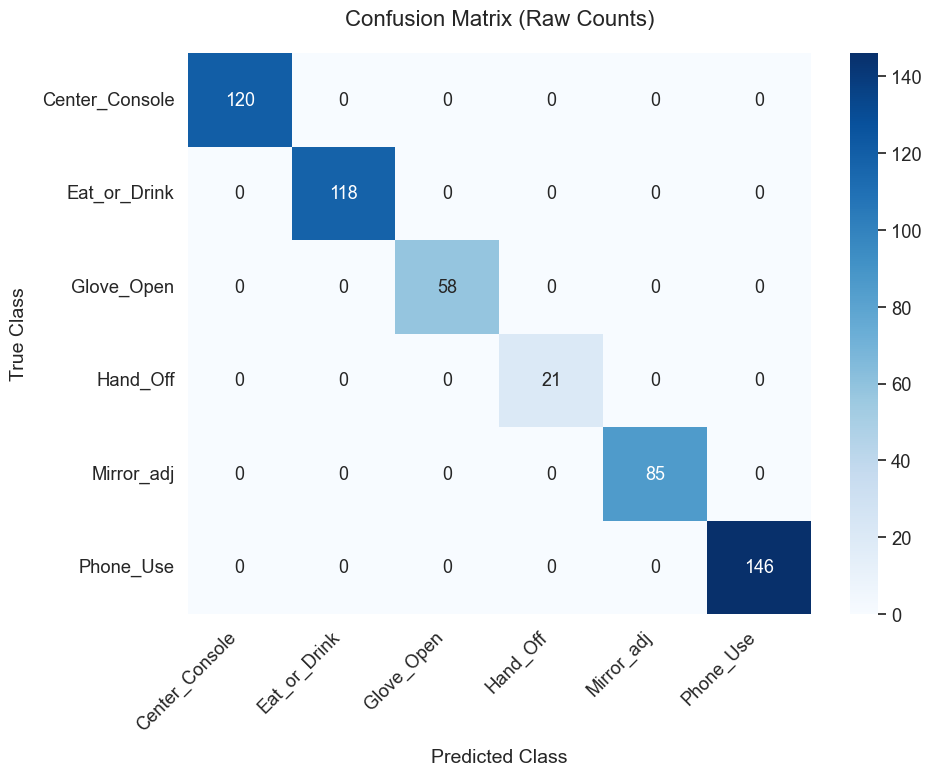

✅ Successfully plotted matrix with raw image counts: /content/drive/MyDrive/fyp1/confusion_matrix_raw_counts.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# 1. Load your trained model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Run validation to get metrics
metrics = model.val(data='/content/FYP-2-74/data.yaml', split='val')

# 3. Get the raw internal confusion matrix array from Ultralytics
# Ultralytics stores this as a numpy array with background at the last row/col index
raw_matrix = metrics.confusion_matrix.matrix

# 4. Extract class names from model
class_names = list(model.names.values())
num_classes = len(class_names)

# 5. Crop the background row and column (keeping only your actual classes)
matrix_no_bg = raw_matrix[:num_classes, :num_classes].astype(int)

# 6. Plotting the Confusion Matrix with Raw Counts
plt.figure(figsize=(10, 8))
sns.set_theme(style="white", font_scale=1.2)

# Create the heatmap with raw integer counts explicitly shown
sns.heatmap(
    matrix_no_bg,
    annot=True,                                  # Enables display of numbers inside the boxes
    fmt="d",                                     # Forces numbers to display as integers (e.g., 120, 58)
    cmap="Blues",                                # Color gradient matching your image
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 13, "fontweight": "bold"} # Keeps font bold and clear
)

plt.title('Confusion Matrix (Raw Counts)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=14, labelpad=10)
plt.ylabel('True Class', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right')              # Rotates labels for neat layout
plt.yticks(rotation=0)
plt.tight_layout()

# 7. Save and Show the Result
output_img_path = '/content/drive/MyDrive/fyp1/confusion_matrix_raw_counts.png'
plt.savefig(output_img_path, dpi=300)
plt.show()

print(f"✅ Successfully plotted matrix with raw image counts: {output_img_path}")

In [ ]:
import cv2
import torch
import gc
from ultralytics import YOLO

# 1. Load Model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Setup Paths
video_path = '/content/drive/MyDrive/fyp1/3-car.mp4'
output_path = '/content/drive/MyDrive/fyp1/3-car_Result1.mp4'

cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

# 3. Prediction Settings
use_half = True if torch.cuda.is_available() else False

results = model.predict(
    source=video_path,
    half=use_half,
    stream=True,
    agnostic_nms=True,
    conf=0.5
)

# --- TRACKING VARIABLES ---
distraction_frames = 0
empty_frames_count = 0
grace_period_seconds = 0.5
grace_period_frames = int(grace_period_seconds * fps) # 0.5s delay buffer

print(f"Processing... Video FPS: {fps} | Grace Period: {grace_period_frames} frames")

# 4. The Processing Loop
for r in results:
    annotated_frame = r.plot()

    if len(r.boxes) > 0:
        # Distraction detected: Reset the "absence" counter and increment timer
        distraction_frames += 1
        empty_frames_count = 0
    else:
        # No distraction detected in this specific frame
        empty_frames_count += 1

        # Only reset the timer if the person is "gone" for more than 0.5s
        if empty_frames_count > grace_period_frames:
            distraction_frames = 0
        else:
            # Continue counting during the 0.5s grace period to keep the UI smooth
            if distraction_frames > 0:
                distraction_frames += 1

    # Calculate time based on accumulated frames
    elapsed_video_time = distraction_frames / fps

    # 5. Drawing Logic
    if distraction_frames > 0:
        timer_text = f"Timer: {elapsed_video_time:.1f}s"

        # --- TIMER TEXT (BLACK) ---
        # First: Draw a white outline (thickness 4) so black text is visible on dark backgrounds
        cv2.putText(annotated_frame, timer_text, (50, 150),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 4)

        # Second: Draw the main Black text (thickness 2) on top
        cv2.putText(annotated_frame, timer_text, (50, 150),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

        # --- TRIGGER ALERTS ---
        if elapsed_video_time >= 5.0:
            cv2.putText(annotated_frame, "DISTRACTED!", (50, 100),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3)
        elif elapsed_video_time >= 2.0:
            cv2.putText(annotated_frame, "WARNING", (50, 100),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 255), 2)

    out.write(annotated_frame)

    del r
    gc.collect()

# 6. Cleanup
cap.release()
out.release()
print(f"✅ Done! Result saved to: {output_path}")

Streaming output truncated to the last 5000 lines.
video 1/1 (frame 6116/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 20.1ms
video 1/1 (frame 6117/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 14.0ms
video 1/1 (frame 6118/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 14.6ms
video 1/1 (frame 6119/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 13.8ms
video 1/1 (frame 6120/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 13.3ms
video 1/1 (frame 6121/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 14.6ms
video 1/1 (frame 6122/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 13.6ms
video 1/1 (frame 6123/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 14.2ms
video 1/1 (frame 6124/11113) /content/drive/MyDrive/fyp1/3-car.mp4: 384x640 (no detections), 13.6ms
video 1/1 (frame 6125/11113) /content/drive/MyDri

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="vjuNLaTJfHC9loP7x85R")
project = rf.workspace("kangs-workspace-sc5tk").project("fyp-2-bglcr")
version = project.version(61)
dataset = version.download("yolov11")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to FYP-2-61 in yolov11:: 100%|██████████| 3821/3821 [00:00<00:00, 6559.17it/s]


In [ ]:
!nvidia-smi

Tue Apr 21 08:46:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.3 MB/s eta 0:00:00


In [ ]:
!yolo detect train data=/content/FYP-2-61/data.yaml model=yolo11n.pt epochs=100 batch=8 lr0=0.01

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FYP-2-61/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

In [ ]:
from google.colab import drive
import shutil
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define exactly where the file is, and where it should go
source_path = '/content/runs/detect/train/weights/best.pt'
destination_path = '/content/drive/MyDrive/yolov11.pt'

# 3. Copy and rename the file
if os.path.exists(source_path):
    shutil.copy(source_path, destination_path)
    print(f"Success! File saved to your Google Drive as: {destination_path}")
else:
    print(f"Error: Could not find the trained weights at {source_path}. Please check the folder path.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Success! File saved to your Google Drive as: /content/drive/MyDrive/yolov11.pt


In [ ]:
from google.colab import files

# Replace the path below with the actual location of your trained model
# Usually, it is in 'runs/detect/train/weights/best.pt'
model_path = 'runs/detect/train/weights/best.pt'

files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import time
import torch
from ultralytics import YOLO

# 1. Load Model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Setup Paths
video_path = '/content/drive/MyDrive/Fyp/final.mp4'
output_path = '/content/drive/MyDrive/Fyp/Triggerfinal1_Result.mp4'

cap = cv2.VideoCapture(video_path)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = int(cap.get(cv2.CAP_PROP_FPS))
w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

# 3. Optimized Prediction Settings
# Check if GPU is available for half-precision
use_half = True if torch.cuda.is_available() else False

results = model.predict(
    source=video_path,
    conf=0.25,
    iou=0.45,
    stream=True,     # CRITICAL: Processes frame-by-frame to prevent RAM crash
    agnostic_nms=True
)

detection_start_time = None

print(f"Processing... GPU acceleration: {use_half}")

# 4. The Processing Loop
for r in results:
    # Get the frame with YOLO's default boxes drawn
    annotated_frame = r.plot()

    # Logic: If there's a detection in the current frame
    if len(r.boxes) > 0:
        if detection_start_time is None:
            detection_start_time = time.time()

        elapsed = time.time() - detection_start_time

        # Overlay your FYP distraction alerts
        if elapsed >= 5:
            cv2.putText(annotated_frame, "!!! DISTRACT !!!", (50, 100),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3)
        elif elapsed >= 2:
            cv2.putText(annotated_frame, "WARNING", (50, 100),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 255), 2)
    else:
        # Reset timer if no hand is detected
        detection_start_time = None

    # Write the frame to the output file
    out.write(annotated_frame)

# 5. Cleanup
cap.release()
out.release()
print(f"✅ Finished! Video saved to: {output_path}")

Processing... GPU acceleration: True

video 1/1 (frame 1/4193) /content/drive/MyDrive/Fyp/final.mp4: 384x640 1 MANUAL, 12.6ms
video 1/1 (frame 2/4193) /content/drive/MyDrive/Fyp/final.mp4: 384x640 (no detections), 26.6ms
video 1/1 (frame 3/4193) /content/drive/MyDrive/Fyp/final.mp4: 384x640 (no detections), 24.8ms
video 1/1 (frame 4/4193) /content/drive/MyDrive/Fyp/final.mp4: 384x640 (no detections), 24.6ms
video 1/1 (frame 5/4193) /content/drive/MyDrive/Fyp/final.mp4: 384x640 (no detections), 41.4ms
video 1/1 (frame 6/4193) /content/drive/MyDrive/Fyp/final.mp4: 384x640 (no detections), 22.4ms
video 1/1 (frame 7/4193) /content/drive/MyDrive/Fyp/final.mp4: 384x640 (no detections), 31.8ms
video 1/1 (frame 8/4193) /content/drive/MyDrive/Fyp/final.mp4: 384x640 (no detections), 20.9ms
video 1/1 (frame 9/4193) /content/drive/MyDrive/Fyp/final.mp4: 384x640 (no detections), 23.7ms
video 1/1 (frame 10/4193) /content/drive/MyDrive/Fyp/final.mp4: 384x640 (no detections), 38.3ms
video 1/1 (frame 1

In [ ]:
!yolo detect predict \
model=/content/runs/detect/train/weights/best.pt \
source='/content/drive/MyDrive/Fyp/finaltest.mp4' \
save=True

Streaming output truncated to the last 5000 lines.
video 1/1 (frame 207/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 384x640 1 MANUAL, 22.5ms
video 1/1 (frame 208/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 384x640 1 VISUAL, 12.0ms
video 1/1 (frame 209/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 384x640 1 MANUAL, 1 VISUAL, 12.8ms
video 1/1 (frame 210/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 384x640 1 MANUAL, 1 VISUAL, 12.3ms
video 1/1 (frame 211/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 384x640 1 VISUAL, 12.5ms
video 1/1 (frame 212/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 384x640 (no detections), 12.1ms
video 1/1 (frame 213/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 384x640 (no detections), 11.9ms
video 1/1 (frame 214/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 384x640 1 VISUAL, 11.8ms
video 1/1 (frame 215/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 384x640 1 VISUAL, 12.4ms
video 1/1 (frame 216/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 

In [ ]:
import cv2
import time
from ultralytics import YOLO
from google.colab.patches import cv2_imshow # For Colab image display

# 1. Load Model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Setup Video Paths
video_path = '/content/drive/MyDrive/Fyp/finaltest.mp4'
output_path = '/content/drive/MyDrive/Fyp/finaltest_Result.mp4'
cap = cv2.VideoCapture(video_path)

# Get video properties for saving
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = int(cap.get(cv2.CAP_PROP_FPS))
w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

detection_start_time = None

while cap.isOpened():
    success, frame = cap.read()
    if not success: break

    results = model(frame, verbose=False)
    annotated_frame = results[0].plot() # Draw the YOLO boxes

    if len(results[0].boxes) > 0:
        if detection_start_time is None:
            detection_start_time = time.time()

        elapsed = time.time() - detection_start_time

        # Draw status on the video frame
        if elapsed >= 5:
            cv2.putText(annotated_frame, "DISTRACT", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)
        elif elapsed >= 2:
            cv2.putText(annotated_frame, "WARNING", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
    else:
        detection_start_time = None

    out.write(annotated_frame)

cap.release()
out.release()
print(f"✅ Done! You can see your result here: {output_path}")

✅ Done! You can see your result here: /content/drive/MyDrive/Fyp/finaltest_Result.mp4


In [ ]:
from ultralytics import YOLO
import os

# 1. Load your best trained model (from your FYP training)
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Path to your video in Google Drive
# TIP: Right-click the file in the Colab sidebar and select "Copy path"
video_input_path = '/content/drive/MyDrive/Fyp/finaltest.mp4'

# 3. Run prediction
results = model.predict(
    source=video_input_path,
    conf=0.25,           # Confidence threshold
    iou=0.45,            # Fixes the "Double Detection" issue
    agnostic_nms=True,   # Important for overlapping "Manual" distractions
    save=True            # Saves the output video
)

print(f"Success! Video saved to: {results[0].save_dir}")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 384x640 1 MANUAL, 49.2ms
video 1/1 (frame 2/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 384x640 1 MANUAL, 14.8ms
video 1/1 (frame 3/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 384x640 (no detections), 13.4ms
video 1/1 (frame 4/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 384x640 (no detections), 11.8ms
video 1/1 (frame 5/5203) /content/drive/MyDrive/Fyp/finaltest.mp4: 384x640 (

In [ ]:
from ultralytics import YOLO

# 1. Load your best model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Run the prediction on your validation images
# This command CREATES the 'predict' folder
results = model.predict(
    source='/content/FYP-2-450/valid/images',
    conf=0.25,
    iou=0.45,
    agnostic_nms=True,
    save=True
)

FileNotFoundError: /content/FYP-2-450/valid/images does not exist

In [ ]:
import cv2
import time
from ultralytics import YOLO
from google.colab.patches import cv2_imshow # For Colab image display

# 1. Load Model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Setup Video Paths
video_path = '/content/drive/MyDrive/Fyp/test1.mp4'
output_path = '/content/drive/MyDrive/Fyp/Triggertest11_Result.mp4'
cap = cv2.VideoCapture(video_path)

# Get video properties for saving
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = int(cap.get(cv2.CAP_PROP_FPS))
w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

detection_start_time = None

while cap.isOpened():
    success, frame = cap.read()
    if not success: break

    results = model(frame, verbose=False)
    annotated_frame = results[0].plot() # Draw the YOLO boxes

    if len(results[0].boxes) > 0:
        if detection_start_time is None:
            detection_start_time = time.time()

        elapsed = time.time() - detection_start_time

        # Draw status on the video frame
        if elapsed >= 5:
            cv2.putText(annotated_frame, "DISTRACT", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)
        elif elapsed >= 2:
            cv2.putText(annotated_frame, "WARNING", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
    else:
        detection_start_time = None

    out.write(annotated_frame)

cap.release()
out.release()
print(f"✅ Done! You can see your result here: {output_path}")

✅ Done! You can see your result here: /content/drive/MyDrive/Fyp/Triggertest11_Result.mp4


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/haha/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, kera

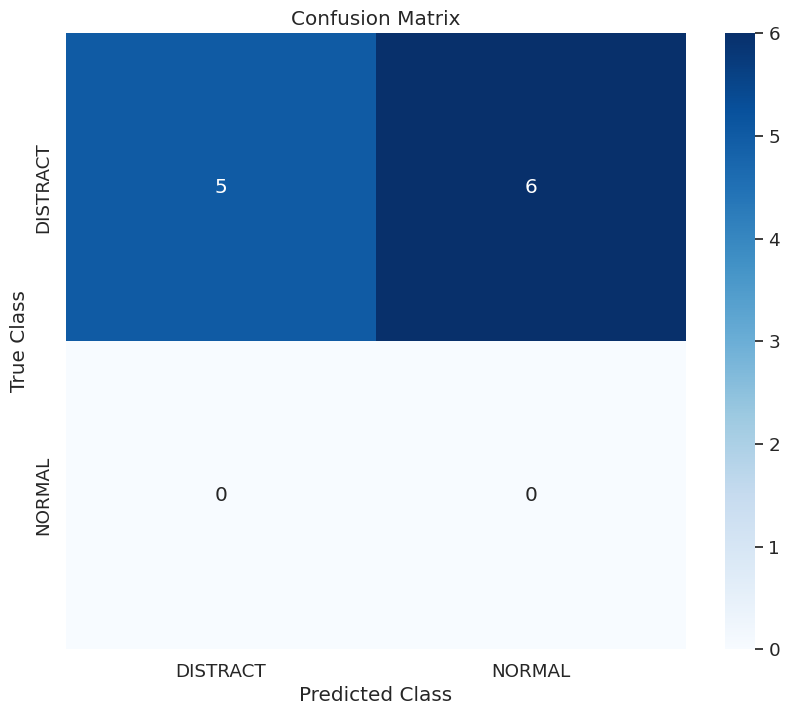

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np
from ultralytics import YOLO

# 1. LOAD & TRAIN (Adjust hyperparameters here)
model = YOLO('yolo11n.pt')

model.train(
    data='/content/haha/data.yaml',
    epochs=20,
    batch=8,
    lr0=0.01,
    imgsz=640
)

# 2. VALIDATE to get the confusion matrix data
results = model.val()

# 3. EXTRACT DATA
# results.confusion_matrix.matrix contains the raw integer counts
full_matrix = results.confusion_matrix.matrix
class_names = list(model.names.values())

# Remove Background row and column (last index)
clean_matrix = full_matrix[:-1, :-1]

# 4. PLOT WITH IMAGE COUNTS
plt.figure(figsize=(10, 8))
sn.set_theme(font_scale=1.2)

# Change fmt='.0f' to show the number of images as integers
sn.heatmap(
    clean_matrix,
    annot=True,
    fmt='.0f',      # This ensures whole numbers (image counts) are shown
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

In [ ]:
import pandas as pd

# 1. Get raw counts from your clean matrix
# clean_matrix[row][column] -> [True][Predicted]
tp_distract = clean_matrix[0, 0]  # True Positives for DISTRACT
fp_distract = clean_matrix[1, 0]  # Normal predicted as Distract
fn_distract = clean_matrix[0, 1]  # Distract predicted as Normal

tp_normal = clean_matrix[1, 1]    # True Positives for NORMAL
fp_normal = clean_matrix[0, 1]    # Distract predicted as Normal
fn_normal = clean_matrix[1, 0]    # Normal predicted as Distract

# 2. Calculate Metrics
def get_metrics(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

p_dist, r_dist, f1_dist = get_metrics(tp_distract, fp_distract, fn_distract)
p_norm, r_norm, f1_norm = get_metrics(tp_normal, fp_normal, fn_normal)

# 3. Create a Performance Table
performance_data = {
    'Class': ['DISTRACT', 'NORMAL'],
    'Precision': [f"{p_dist:.2f}", f"{p_norm:.2f}"],
    'Recall': [f"{r_dist:.2f}", f"{r_norm:.2f}"],
    'F1-Score': [f"{f1_dist:.2f}", f"{f1_norm:.2f}"]
}

df_performance = pd.DataFrame(performance_data)
print("\n--- Performance Matrix ---")
print(df_performance.to_string(index=False))


--- Performance Matrix ---
   Class Precision Recall F1-Score
DISTRACT      1.00   0.45     0.62
  NORMAL      0.00   0.00     0.00


In [ ]:
# Assuming you have already run: results = model.val()

# Print the overall summary of metrics
print(f"mAP50: {results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95: {results.results_dict['metrics/mAP50-95(B)']:.4f}")
print(f"Precision: {results.results_dict['metrics/precision(B)']:.4f}")
print(f"Recall: {results.results_dict['metrics/recall(B)']:.4f}")

mAP50: 0.8725
mAP50-95: 0.7562
Precision: 0.6366
Recall: 0.8376


### Training and Validation Performance Graphs

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the path to the results CSV file
# This path is typically where Ultralytics saves its training results.
results_csv_path = '/content/runs/detect/train/results.csv'

# Load the CSV data
if os.path.exists(results_csv_path):
    results_df = pd.read_csv(results_csv_path)
    print(f"Successfully loaded results from: {results_csv_path}")
else:
    print(f"Error: The file {results_csv_path} was not found. Please ensure training has been run and the path is correct.")
    results_df = pd.DataFrame() # Create an empty DataFrame to prevent errors later

display(results_df.head())

Error: The file /content/runs/detect/train/results.csv was not found. Please ensure training has been run and the path is correct.


""


In [ ]:
if not results_df.empty:
    plt.figure(figsize=(16, 7))

    # Plot Training Losses
    plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
    sns.lineplot(data=results_df[['train/box_loss', 'train/cls_loss', 'train/dfl_loss']])
    plt.title('Training Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend(title='Loss Type')

    # Plot Validation Losses
    plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
    sns.lineplot(data=results_df[['val/box_loss', 'val/cls_loss', 'val/dfl_loss']])
    plt.title('Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend(title='Loss Type')

    plt.tight_layout()

    # Save the plot to Google Drive
    output_plot_path_loss = '/content/drive/MyDrive/fyp1/training_validation_loss_graph.png'
    plt.savefig(output_plot_path_loss, dpi=300)
    plt.show()
    print(f"✅ Training and Validation Loss Graph saved to: {output_plot_path_loss}")
else:
    print("Cannot plot loss graphs: results_df is empty or could not be loaded.")

Cannot plot loss graphs: results_df is empty or could not be loaded.


In [ ]:
if not results_df.empty:
    plt.figure(figsize=(12, 6))

    # Plot Accuracy Metrics
    # Ultralytics typically provides mAP50 and mAP50-95 for object detection accuracy
    sns.lineplot(data=results_df[['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']])
    plt.title('Training and Validation Accuracy Metrics Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Metric Value')
    plt.grid(True)
    plt.legend(loc='lower right', title='Metric')

    plt.tight_layout()

    # Save the plot to Google Drive
    output_plot_path_accuracy = '/content/drive/MyDrive/fyp1/training_validation_accuracy_graph.png'
    plt.savefig(output_plot_path_accuracy, dpi=300)
    plt.show()
    print(f"✅ Training and Validation Accuracy Graph saved to: {output_plot_path_accuracy}")
else:
    print("Cannot plot accuracy graphs: results_df is empty or could not be loaded.")

Cannot plot accuracy graphs: results_df is empty or could not be loaded.


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="LLbtqRjSQ6EpTwmF0il2")
project = rf.workspace("john-wick-vrzpu").project("normal-744o5")
version = project.version(5)
dataset = version.download("yolov11")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 133.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to NORMAL-5 in yolov11:: 100%|██████████| 212/212 [00:00<00:00, 3652.09it/s]


In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.2 MB/s eta 0:00:00


In [ ]:
!yolo detect train data=/content/HAHA/data.yaml model=yolo11n.pt epochs=20 batch=8 lr0=0.01

Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/HAHA/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose

In [ ]:
!yolo detect val data=/content/HAHA/data.yaml model=/content/runs/detect/train5/weights/best.pt

Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2854.2±376.5 MB/s, size: 240.2 KB)
val: Scanning /content/HAHA/valid/labels.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 4.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.4it/s 0.8s
                   all         20         20      0.637      0.838      0.873      0.756
              DISTRACT          5          5      0.273          1      0.815      0.723
                NORMAL         15         15          1      0.675       0.93      0.789
Speed: 0.5ms preprocess, 27.6ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


### Training and Validation Performance Graphs

In [ ]:
# 1. Mount Google Drive (if not already mounted)
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the path to the results CSV file
# This path is typically where Ultralytics saves its training results.
results_csv_path = '/content/drive/MyDrive/fyp1/finalyolov11_results.csv'
# Load the CSV data
if os.path.exists(results_csv_path):
    results_df = pd.read_csv(results_csv_path)
    print(f"Successfully loaded results from: {results_csv_path}")
else:
    print(f"Error: The file {results_csv_path} was not found. Please ensure training has been run and the path is correct.")
    results_df = pd.DataFrame() # Create an empty DataFrame to prevent errors later

display(results_df.head())

Successfully loaded results from: /content/drive/MyDrive/fyp1/finalyolov11_results.csv


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,126.204,1.24742,2.88046,1.30724,0.84843,0.86947,0.92682,0.67404,0.95557,0.98997,0.99429,0.000333,0.000333,0.000333
1,2,218.756,1.05836,1.50659,1.14196,0.93384,0.93839,0.96725,0.75081,0.87886,0.82476,0.98309,0.000659,0.000659,0.000659
2,3,309.237,1.05298,1.14689,1.13281,0.92732,0.93794,0.98348,0.74829,0.90062,0.60520,0.97773,0.000980,0.000980,0.000980
3,4,398.740,0.99544,0.92035,1.09948,0.94838,0.96252,0.98401,0.77165,0.84090,0.56316,0.97239,0.000970,0.000970,0.000970
4,5,489.085,0.94314,0.83382,1.07888,0.97054,0.96383,0.97062,0.76138,0.83189,0.55221,0.94664,0.000960,0.000960,0.000960


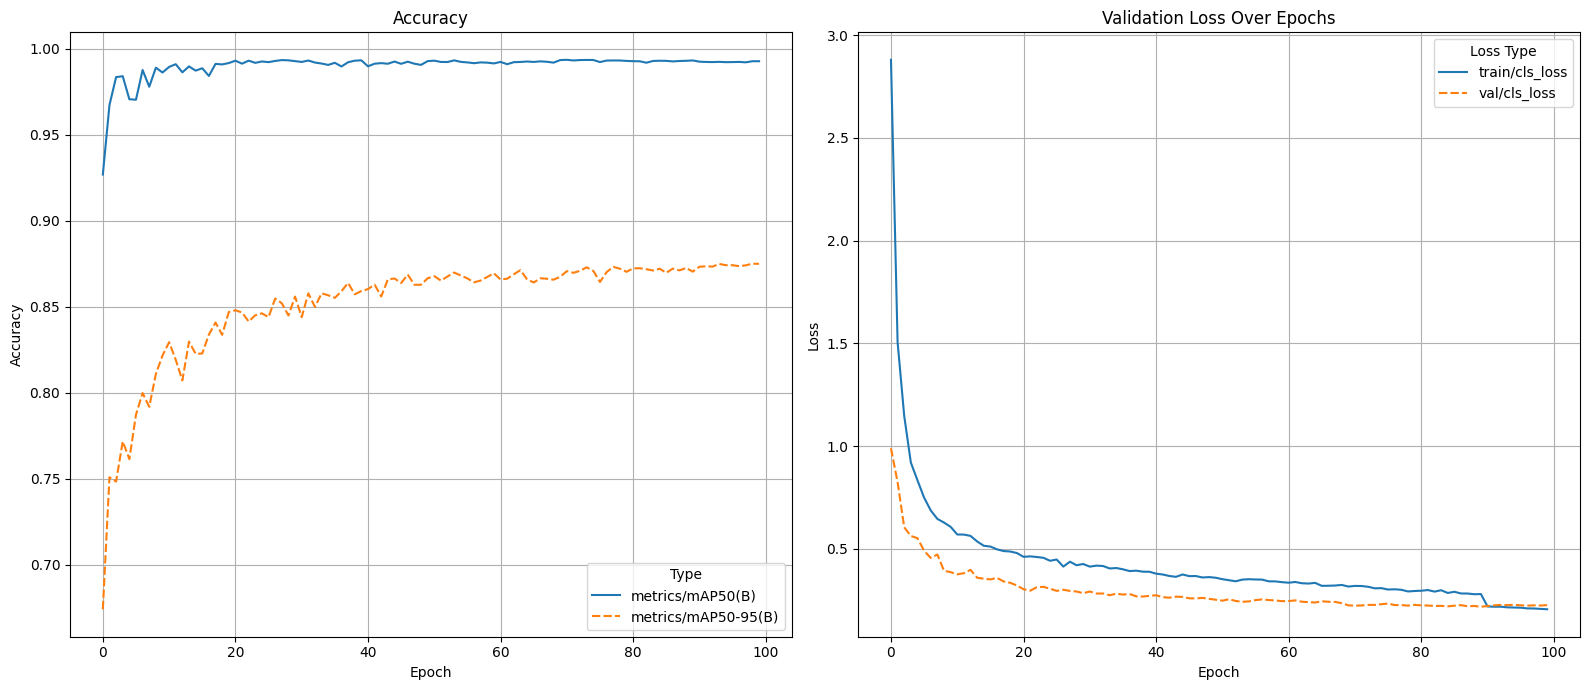

✅ Training and Validation Loss Graph saved to: /content/drive/MyDrive/fyp1/training_validation_loss_graph.png


In [ ]:
if not results_df.empty:
    plt.figure(figsize=(16, 7))

    # Plot Training Losses
    plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
    sns.lineplot(data=results_df[['metrics/mAP50(B)','metrics/mAP50-95(B)']])
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend(title='Type')

    # Plot Validation Losses
    plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
    sns.lineplot(data=results_df[['train/cls_loss', 'val/cls_loss']])
    plt.title('Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend(title='Loss Type')

    plt.tight_layout()

    # Save the plot to Google Drive
    output_plot_path_loss = '/content/drive/MyDrive/fyp1/training_validation_loss_graph.png'
    plt.savefig(output_plot_path_loss, dpi=300)
    plt.show()
    print(f"✅ Training and Validation Loss Graph saved to: {output_plot_path_loss}")
else:
    print("Cannot plot loss graphs: results_df is empty or could not be loaded.")

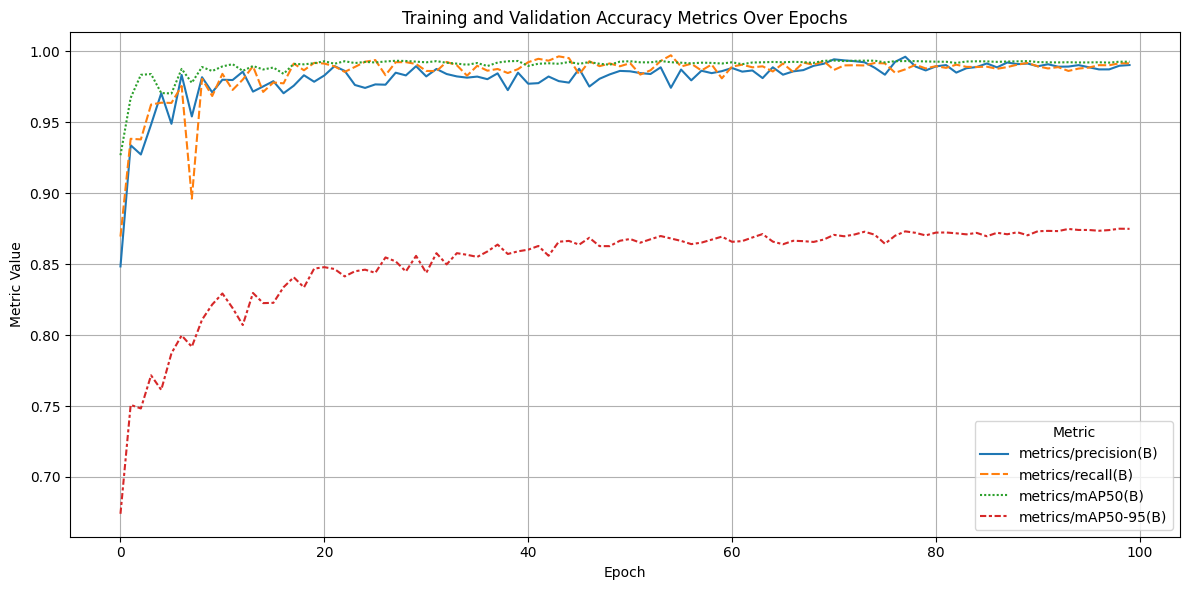

✅ Training and Validation Accuracy Graph saved to: /content/drive/MyDrive/fyp1/training_validation_accuracy_graph.png


In [ ]:
if not results_df.empty:
    plt.figure(figsize=(12, 6))

    # Plot Accuracy Metrics
    # Ultralytics typically provides mAP50 and mAP50-95 for object detection accuracy
    sns.lineplot(data=results_df[['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']])
    plt.title('Training and Validation Accuracy Metrics Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Metric Value')
    plt.grid(True)
    plt.legend(loc='lower right', title='Metric')

    plt.tight_layout()

    # Save the plot to Google Drive
    output_plot_path_accuracy = '/content/drive/MyDrive/fyp1/training_validation_accuracy_graph.png'
    plt.savefig(output_plot_path_accuracy, dpi=300)
    plt.show()
    print(f"✅ Training and Validation Accuracy Graph saved to: {output_plot_path_accuracy}")
else:
    print("Cannot plot accuracy graphs: results_df is empty or could not be loaded.")

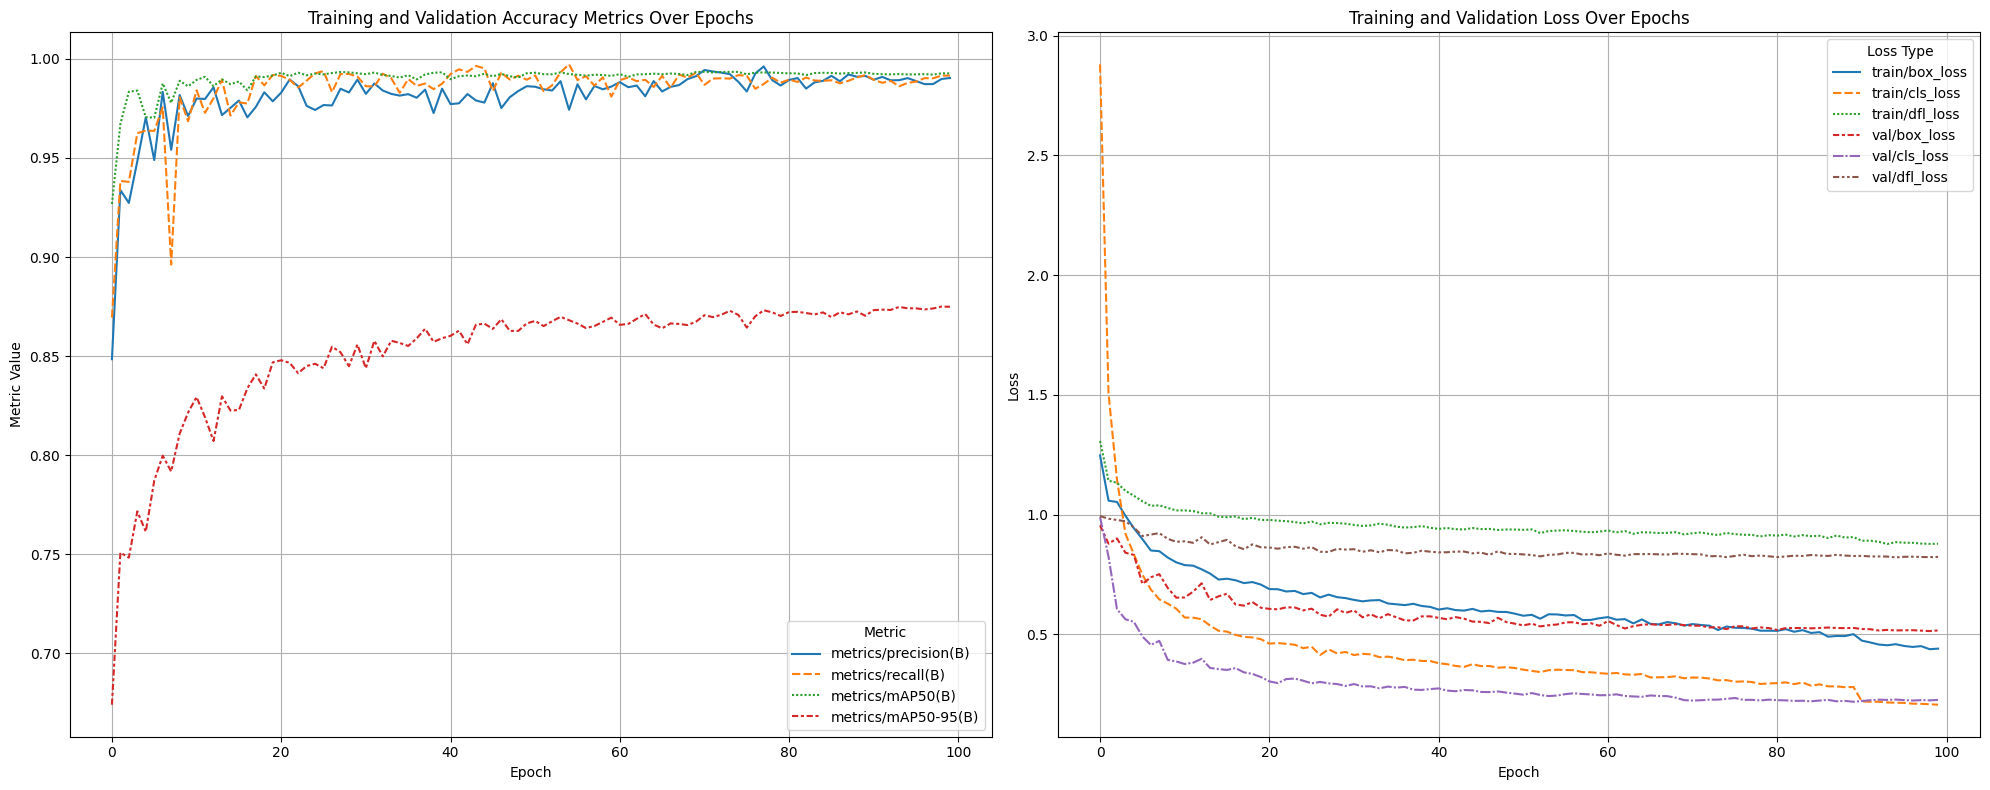

✅ Combined Training and Validation Performance Graph saved to: /content/drive/MyDrive/fyp1/training_validation_performance_combined.png


In [ ]:
if not results_df.empty:
    plt.figure(figsize=(20, 8))

    # Subplot 1: Accuracy Metrics
    plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
    sns.lineplot(data=results_df[['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']])
    plt.title('Training and Validation Accuracy Metrics Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Metric Value')
    plt.grid(True)
    plt.legend(loc='lower right', title='Metric')

    # Subplot 2: Loss Metrics
    plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
    sns.lineplot(data=results_df[['train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss']])
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend(title='Loss Type')

    plt.tight_layout()

    # Save the combined plot to Google Drive
    output_plot_path_combined = '/content/drive/MyDrive/fyp1/training_validation_performance_combined.png'
    plt.savefig(output_plot_path_combined, dpi=300)
    plt.show()
    print(f"✅ Combined Training and Validation Performance Graph saved to: {output_plot_path_combined}")
else:
    print("Cannot plot combined graphs: results_df is empty or could not be loaded.")

---

Feel free to ask if you'd like to dive deeper into any of these areas or generate code for a specific task!